In [4]:
CAPTIONS_PATH = "/ghome/c5mcv07/C5_G7_MCV/Image_Captioning_Utils/dataset/Food Ingredients and Recipe Dataset with Image Name Mapping.csv"

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from collections import Counter

%matplotlib inline

# Load the dataset
df = pd.read_csv(CAPTIONS_PATH, index_col=False)

In [6]:
df.head()

,Unnamed: 0,Title,Ingredients,Instructions,Image_Name,Cleaned_Ingredients
0,0,Miso-Butter Roast Chicken With Acorn Squash Pa...,"['1 (3½–4-lb.) whole chicken', '2¾ tsp. kosher...","Pat chicken dry with paper towels, season all ...",miso-butter-roast-chicken-acorn-squash-panzanella,"['1 (3½–4-lb.) whole chicken', '2¾ tsp. kosher..."
1,1,Crispy Salt and Pepper Potatoes,"['2 large egg whites', '1 pound new potatoes (...",Preheat oven to 400°F and line a rimmed baking...,crispy-salt-and-pepper-potatoes-dan-kluger,"['2 large egg whites', '1 pound new potatoes (..."
2,2,Thanksgiving Mac and Cheese,"['1 cup evaporated milk', '1 cup whole milk', ...",Place a rack in middle of oven; preheat to 400...,thanksgiving-mac-and-cheese-erick-williams,"['1 cup evaporated milk', '1 cup whole milk', ..."
3,3,Italian Sausage and Bread Stuffing,"['1 (¾- to 1-pound) round Italian loaf, cut in...",Preheat oven to 350°F with rack in middle. Gen...,italian-sausage-and-bread-stuffing-240559,"['1 (¾- to 1-pound) round Italian loaf, cut in..."
4,4,Newton's Law,"['1 teaspoon dark brown sugar', '1 teaspoon ho...",Stir together brown sugar and hot water in a c...,newtons-law-apple-bourbon-cocktail,"['1 teaspoon dark brown sugar', '1 teaspoon ho..."


In [11]:
# %% [markdown]
# ## Extract Captions and Compute Caption Lengths
# 
# Here we focus on the `Title` column. We calculate the number of words in each caption.

# %% [code]
# Calculate the number of words in each title
df['word_count'] = df['Title'].apply(lambda x: len(str(x).split(" ")))

# Show the Title and its word count
print(df[['Title', 'word_count']].head())


                                               Title  word_count
0  Miso-Butter Roast Chicken With Acorn Squash Pa...           7
1                    Crispy Salt and Pepper Potatoes           5
2                        Thanksgiving Mac and Cheese           4
3                 Italian Sausage and Bread Stuffing           5
4                                       Newton's Law           2


count    13501.000000
mean         4.772906
std          2.271037
min          1.000000
25%          3.000000
50%          4.000000
75%          6.000000
max         22.000000
Name: word_count, dtype: float64


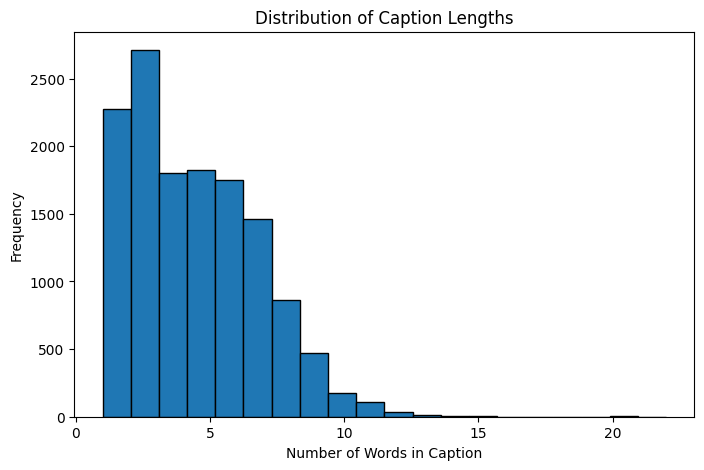

In [12]:

# %% [markdown]
# ## Descriptive Statistics and Histogram
# 
# We get a summary of the word counts and plot their distribution.

# %% [code]
# Print descriptive statistics of caption lengths
print(df['word_count'].describe())

# Plot a histogram of caption lengths
plt.figure(figsize=(8, 5))
plt.hist(df['word_count'], bins=20, edgecolor='black')
plt.xlabel('Number of Words in Caption')
plt.ylabel('Frequency')
plt.title('Distribution of Caption Lengths')
plt.show()


Top 10 words: [('with', 5272), ('and', 4309), ('salad', 959), ('chicken', 851), ('sauce', 678), ('grilled', 570), ('cake', 450), ('roasted', 443), ('chocolate', 427), ('cream', 405)]


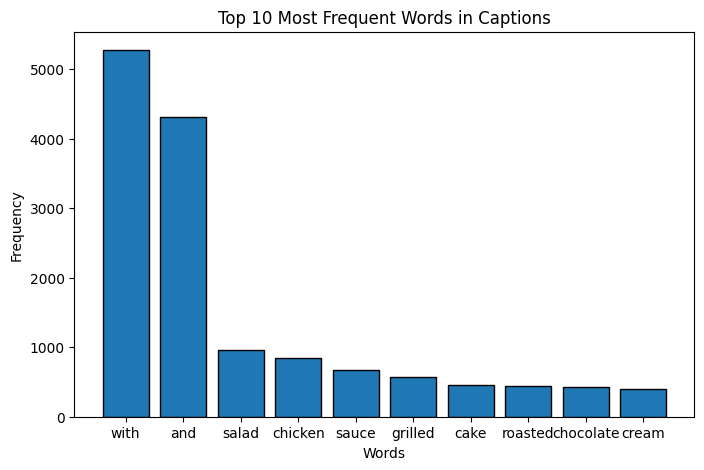

In [6]:
# %% [markdown]
# ## Word Frequency Analysis
# 
# In this section, we combine all captions into one text, clean it by removing punctuation and converting to lowercase,
# and then count the frequency of each word. Finally, we plot the top 10 most frequent words.

# %% [code]
# Define a function to clean text (remove punctuation and lowercase)
def clean_text(text):
    text = re.sub(r'[^\w\s]', '', text)
    return text.lower()

# Combine all titles into a single string and clean it
all_titles = " ".join([str(t) for t in df['Title'].tolist()])
all_titles_clean = clean_text(all_titles)

# Split into words and count frequencies
words = all_titles_clean.split()
word_counts = Counter(words)

# Get the top 10 most common words
top_words = word_counts.most_common(10)
print("Top 10 words:", top_words)

# Separate the words and counts for plotting
words_top, counts_top = zip(*top_words)

# Plot a bar chart of the top 10 words
plt.figure(figsize=(8, 5))
plt.bar(words_top, counts_top, edgecolor='black')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.title('Top 10 Most Frequent Words in Captions')
plt.show()

In [7]:

import sys

sys.path.insert(0, "/ghome/c5mcv07/C5_G7_MCV")
from Image_Captioning_Utils.dataset import FoodDatasetWord
from Image_Captioning_Utils.utils import get_train_val_test_annotations_split

splits = get_train_val_test_annotations_split()
train_annotations = splits["train"]
val_annotations = splits["val"]
test_annotations = splits["test"]

test_dataset = FoodDatasetWord(test_annotations)


In [8]:
print(test_annotations)

                                                  Title  \
0                                    Red Hook Criterium   
1                          Chipotle Roast Chicken Tacos   
2                        White Bean Soup with Chive Oil   
3                                     Trout in Riesling   
4                                   Sauteed Skirt Steak   
...                                                 ...   
1343                        Vegetarian Three-Bean Chili   
1344  Spice-Rubbed Duck Legs Braised with Green Oliv...   
1345         Blueberry-Beet Smoothie with Coconut Water   
1346            Smashed Cucumber Salad with Hot Vinegar   
1347                                            Rob Roy   

                                            Ingredients  \
0     ['1½ ounces Zucca Rabarbaro Amaro', '½ ounce g...   
1     ['1/4 cup (1/2 stick) butter, softened', '1 ta...   
2     ['2 cups dried Great Northern or other small w...   
3     ['2 tablespoons (1 oz) unsalted butter plus ad...

Foie Gras with Date Pure and Pomegranate


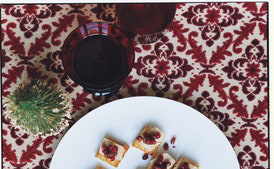

In [9]:
idx = 1057
print(test_dataset[idx][1])
test_dataset[idx][0]

In [1]:

from transformers import VisionEncoderDecoderModel, ViTImageProcessor, AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("nlpconnect/vit-gpt2-image-captioning")
#tokenizer = AutoTokenizer.from_pretrained("gpt2")



In [2]:
print(tokenizer("chocolate with strawberries").input_ids)
print(tokenizer.encode("chocolate with strawberries"))

[354, 9140, 351, 36973]
[354, 9140, 351, 36973]


In [27]:
captions_to_check = ['CaramelizedHoney Nut and Seed Tart', 'CucumberCabbage Salad', 'HerbRoasted Smashed Potatoes', 'Fennel']


print(tokenizer(list(captions_to_check), 
                padding="max_length",
        truncation=True,
        max_length=20,
        add_special_tokens=True,
        return_tensors="pt"))

{'input_ids': tensor([[ 9914, 17983,  1143,    39,  1419, 11959,   290, 23262, 37109, 50256,
         50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256],
        [   34,  1229,  4494,    34, 32061, 42706, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256],
        [ 9360,    65, 15450,  8992,  2439,  5263,  6902, 15048, 50256, 50256,
         50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256],
        [   37,  1697,   417, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])}
